# Week 5 Homework

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(2026)

**1. (35 pts). Labeling an Excavation Site Map. Create a scatter plot representing artifact locations discovered at an archaeological excavation site. Use `ax.text()` to label different find categories and add informative text elements to the visualization.**
- **Use a figure size of 8x8**
- **Plot artifact locations using the provided coordinates for three categories: pottery (6 items), tools (4 items), and bones (5 items)**
- **Use different colors and markers for each category**
- **Label each artifact with its ID (e.g., "P1", "T1", "B1") using `ax.text()` with appropriate offset**
- **Add a site title at the top using `ax.text()` with a bounding box**
- **Include a text box in the corner summarizing total finds per category**
- **Mark the coordinates (5, 5) as the "Datum Point" with bold, rotated text**
- **Use `ax.annotate()` to annotate artifact P4  as an "Obsidian core" using a 'fancy' arrow style with a curved connection style**
- **Similarly, annotate artifact T2 as an "Obsidian Blade" using a '->' arrow style with textcoords='offset points'**

***DATA***

In [30]:
# Artifact coordinates
pottery_coords = [(2, 3), (3, 7), (4, 2), (6, 8), (7, 4), (8, 6)]
tools_coords = [(1, 5), (5, 1), (9, 3), (4, 9)]
bones_coords = [(2, 8), (6, 2), (8, 8), (3, 4), (7, 6)]

Text(30, 0, 'Obsidian Blade')

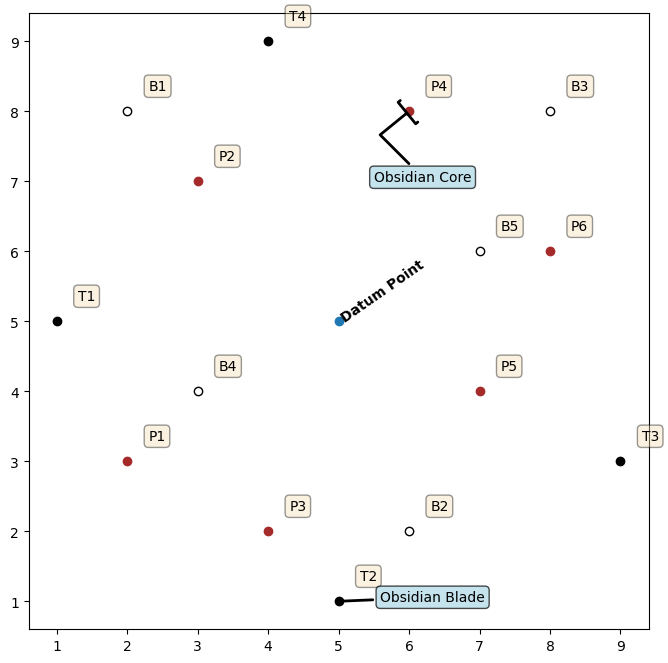

In [31]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(8, 8))
for i, (x, y), in enumerate(pottery_coords):
    ax.plot(x, y, 'o', color='brown')
    ax.text(x + 0.3, y + 0.3,
            s=f'P{i+1}',
            bbox=dict(boxstyle='round', 
                      facecolor='wheat',
                      alpha=0.4))
for i, (x, y), in enumerate(tools_coords):
    ax.plot(x, y, 'o', color='black')
    ax.text(x + 0.3, y + 0.3,
            s=f'T{i+1}',
            bbox=dict(boxstyle='round', 
                      facecolor='wheat',
                      alpha=0.4))
for i, (x, y), in enumerate(bones_coords):
    ax.plot(x, y, 'o', color='white', markeredgecolor='black')
    ax.text(x + 0.3, y + 0.3,
            s=f'B{i+1}',
            bbox=dict(boxstyle='round', 
                      facecolor='wheat',
                      alpha=0.4))
ax.plot(5, 5, 'o')
ax.text(5, 5,
        s='Datum Point',
        rotation=35,
        fontweight='bold')
ax.annotate('Obsidian Core',
            xy= (6, 8),
            xytext= (5.5, 7),
            size=10,
            arrowprops=dict(arrowstyle='-[',
                            connectionstyle='arc, angleA=135, angleB=45,armA=60',
                            color='black',
                            lw=2),
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.annotate('Obsidian Blade',
            xy= (5, 1),
            xytext= (30, 0),
            textcoords='offset points',
            size=10,
            arrowprops=dict(arrowstyle='-',
                            color='black',
                            lw=2),
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

**2. (20 pts) Artifact Assemblage Composition (Donut Chart). An archaeological excavation at a Roman-period site has recovered artifacts from several functional categories. Create a donut chart using Wedge patches to visualize the artifact assemblage composition.**
    
|Artifact Category|Count |Percentage|
|-----------------|------ |----------|
|Ceramics         | 1,245 |   42%    |
|Faunal Remains   | 890   |   30%    |
|Metal Objects    | 385   |   13%    |
|Glass Fragments  | 267   |    9%    |
Worked Stone      | 178   |    6%    |


- **Use Wedge patches with width=0.35 to create a donut chart**
- **Center the chart at (0, 0) with outer radius of 1**
- **Position labels showing category name and count inside the donut ring**
- **Add center text showing the site name "Villa Rustica" and total artifact count**
- **Use an earth-tone color palette ['#8B4513', '#CD853F', '#556B2F', '#708090', '#A0522D']**

*Hint: Calculate label positions at the midpoint angle using radius = outer_radius - width/2.*

***DATA:***

In [32]:
categories = ['Ceramics', 'Faunal Remains', 'Metal Objects', 'Glass Fragments', 'Worked Stone']
counts = [1245, 890, 385, 267, 178]
percentages = [42, 30, 13, 9, 6]
total_artifacts = sum(counts)

# Archaeological earth-tone palette
colors = ['#8B4513', '#CD853F', '#556B2F', '#708090', '#A0522D']

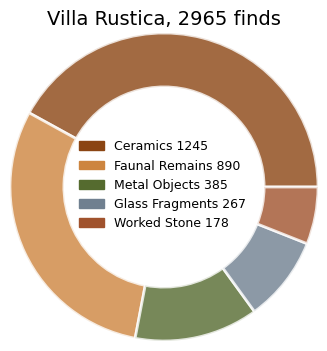

In [60]:
# YOUR CODE 
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(8, 4))

start_angle = 0
for percent, color, cat in zip(percentages, colors, categories):
    angle = percent * (360/100)#translating percentages directly to wedge angles
    wedge = mpatches.Wedge(center=(0, 0), r=1,
                           theta1=start_angle, theta2=start_angle + angle,
                           width= 0.35,
                           fc=color, ec='white', 
                           lw=2, alpha=0.8)
    ax.add_patch(wedge)
    start_angle += angle

# Custom legend handles
legend_handles = [
    mpatches.Patch(color=c, label=f'{cat} {cnt}')
    for cat, cnt, c in zip(categories, counts, colors)
]

ax.legend(#using legend_handle patches to recreate the data attached to the wedges
    handles=legend_handles,
    loc='center',
    bbox_to_anchor=(0.51, 0.5),
    frameon=False,
    bbox_transform=fig.transFigure,
    fontsize=9
)

#cleaning up the axis and creating a title
total_count = sum(counts)
ax.set(xlim= (-1, 1), ylim= (-1, 1), aspect= 'equal')
ax.axis('off')
ax.set_title(f'Villa Rustica, {total_count} finds', size=14)

plt.show()

**3. (45 pts) Stratigraphic profile with phases. You have data from a soil core or excavation trench showing artifact density by depth. Different depth ranges correspond to distinct chronological phases that need to be visually highlighted. Create a visualization that:**
- **Plots artifact density (counts per 10 cm level) using a Line2D artist**
- **Highlights cultural phases using semi-transparent Rectangle patches**
- **Marks significant find depths (e.g., coins, diagnostic pottery) using Circle patches**

**Requirements:**
- **Use a figure size of 10 x 8 and set the aspect ratio of the figure to 0.5**
- **Create the artifact density profile using Line2D (not ax.plot())**
- **Use rectangle patches for each context with distinct color (set transparency to  0.25)**
- **Use circle patches to represent finds at their depths. Label each find**
- **Include a legend explaining all phases and find types**
- **Add appropriate axis labels and title**

*Hint: Use `ax.invert_yaxis()` to display depth increasing downward*

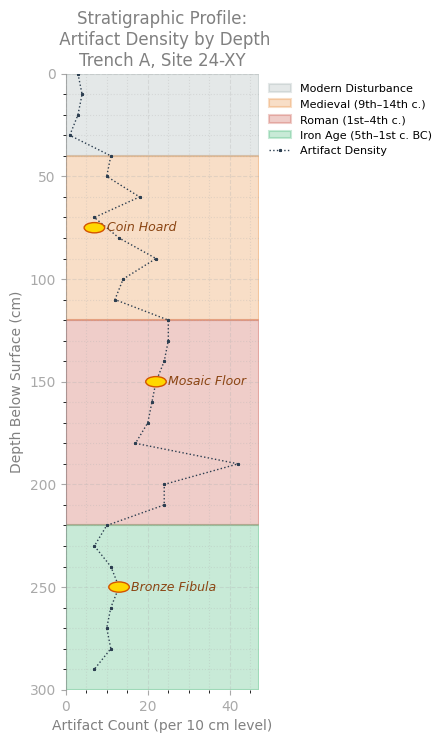

***DATA***

In [62]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

# Generate synthetic excavation data
np.random.seed(2026)
depths = np.arange(0, 300, 10)  # 10 cm levels, 0-290 cm
n_levels = len(depths)

# Create artifact density profile
density = np.zeros(n_levels)
density[0:4] = np.random.poisson(3, 4)        # Modern: sparse
density[4:12] = np.random.poisson(12, 8)      # Medieval: moderate
density[12:22] = np.random.poisson(25, 10)    # Roman: high density
density[22:30] = np.random.poisson(8, 8)      # Iron Age: moderate

# Define cultural phases (start_depth, end_depth, name, color)
cultural_phases = [
    (0, 40, 'Modern Disturbance', '#95a5a6'),
    (40, 120, 'Medieval (9th–14th c.)', '#e67e22'),
    (120, 220, 'Roman (1st–4th c.)', '#c0392b'),
    (220, 300, 'Iron Age (5th–1st c. BC)', '#27ae60') ]

# Significant finds (depth, label)
significant_finds = [
    (75, 'Coin Hoard'),
    (150, 'Mosaic Floor'),
    (250, 'Bronze Fibula') ]

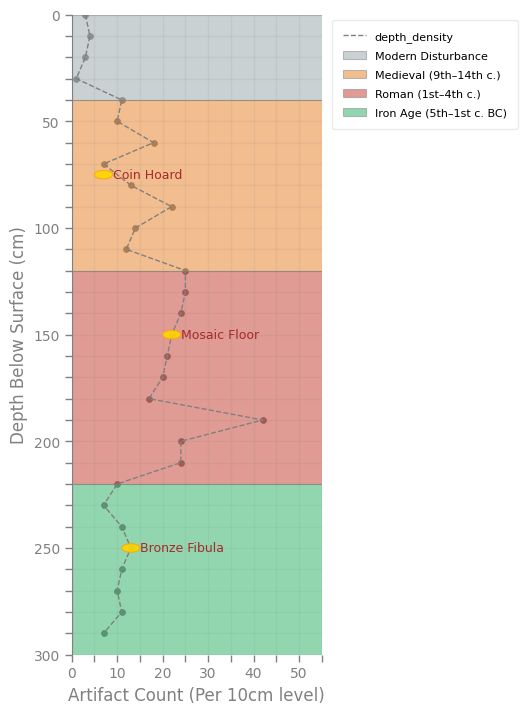

In [128]:
# YOUR CODE HERE
import matplotlib.ticker as ticker
fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0.08, 0.1, 0.25, 0.8])

line = Line2D(density, depths, lw=1, ls='--', color='grey', label='depth_density')

#line and points
ax.add_line(line)
ax.scatter(density, depths, s=15, c='grey')

#axis scaling
ax.set_xlim(0, 55)
ax.set_ylim(0,300)
ax.invert_yaxis()

#labs
ax.set_xlabel('Artifact Count (Per 10cm level)', color='grey', fontsize=12)
ax.set_ylabel('Depth Below Surface (cm)', color='grey', fontsize=12)

#lets do the rectangles
for cp in cultural_phases:
    rect = mpatches.Rectangle((0, cp[0]),
                              width=55, height=(cp[1]-cp[0]),
                              fc=cp[3],ec='grey',
                              lw=.75, alpha=0.5,
                              label= cp[2])
    ax.add_patch(rect)

# lets do circles (significant finds)
for depth, label in significant_finds:
    idx = np.abs(depths - depth).argmin()   # nearest depth index
    x = density[idx]

    circle = mpatches.Circle(
        (x, depth),
        radius=2,
        fc='gold',
        ec='orange',
        lw=0.75,
        alpha=0.9
    )
    circle.set_zorder(3)
    ax.add_patch(circle)
    ax.text(x + 2, depth,  label, va='center', color = 'brown', fontsize=9)
    

legend = ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),   # just to the right of axis
    fontsize=8,
    framealpha=0.4,
    shadow=False,
    borderpad=1,
    labelspacing=0.8
)

# visual markers(ticks,grid)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10.0))
ax.tick_params(axis='both', which='both', 
              length=5, width=1, color='grey', labelcolor='grey')
ax.grid(True, which='both', alpha=0.1, linestyle='-', linewidth=1, color= 'grey')

# set_visible(): get rid off some spines
ax.spines['right'].set_visible(False)  
ax.spines['left'].set_color('grey')
ax.spines['top'].set_visible(False)    
ax.spines['bottom'].set_visible(False)